# Embedding Model

## Automatic Hyperparameter Optimization

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline

c:\Users\tomhi\miniconda3\envs\advml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Data Loading


In [3]:
# Load the data
train_x_df = pd.read_csv('../data/X_train.csv')
train_y_df = pd.read_csv('../data/Y_train.csv')

test_x_df = pd.read_csv('../data/X_test.csv')

C:\Users\tomhi\AppData\Local\Temp\ipykernel_19580\460957917.py:2: DtypeWarning: Columns (0: item21, 1: item22, 2: item23, 3: item24, 4: make21, 5: make22, 6: make23, 7: make24, 8: model21, 9: model22, 10: model23, 11: model24, 12: goods_code1, 13: goods_code8, 14: goods_code9, 15: goods_code10, 16: goods_code11, 17: goods_code12, 18: goods_code13, 19: goods_code14, 20: goods_code15, 21: goods_code16, 22: goods_code17, 23: goods_code18, 24: goods_code19, 25: goods_code20, 26: goods_code21, 27: goods_code22, 28: goods_code23, 29: goods_code24) have mixed types. Specify dtype option on import or set low_memory=False.
  train_x_df = pd.read_csv('../data/X_train.csv')
C:\Users\tomhi\AppData\Local\Temp\ipykernel_19580\460957917.py:5: DtypeWarning: Columns (0: item20, 1: item21, 2: item22, 3: item23, 4: item24, 5: make20, 6: make21, 7: make22, 8: make23, 9: make24, 10: model20, 11: model21, 12: model22, 13: model23, 14: model24, 15: goods_code1, 16: goods_code10, 17: goods_code11, 18: goods_c

### Get Categorical features

In [4]:
item_cols = [f'item{i}' for i in range(1, 25)]
make_cols = [f'make{i}' for i in range(1, 25)]
goods_cols = [f'goods_code{i}' for i in range(1, 25)]

cat_cols = item_cols + make_cols + goods_cols

print(cat_cols)

train_x_df[cat_cols].head()

['item1', 'item2', 'item3', 'item4', 'item5', 'item6', 'item7', 'item8', 'item9', 'item10', 'item11', 'item12', 'item13', 'item14', 'item15', 'item16', 'item17', 'item18', 'item19', 'item20', 'item21', 'item22', 'item23', 'item24', 'make1', 'make2', 'make3', 'make4', 'make5', 'make6', 'make7', 'make8', 'make9', 'make10', 'make11', 'make12', 'make13', 'make14', 'make15', 'make16', 'make17', 'make18', 'make19', 'make20', 'make21', 'make22', 'make23', 'make24', 'goods_code1', 'goods_code2', 'goods_code3', 'goods_code4', 'goods_code5', 'goods_code6', 'goods_code7', 'goods_code8', 'goods_code9', 'goods_code10', 'goods_code11', 'goods_code12', 'goods_code13', 'goods_code14', 'goods_code15', 'goods_code16', 'goods_code17', 'goods_code18', 'goods_code19', 'goods_code20', 'goods_code21', 'goods_code22', 'goods_code23', 'goods_code24']


,item1,item2,item3,item4,item5,item6,item7,item8,item9,item10,...,goods_code15,goods_code16,goods_code17,goods_code18,goods_code19,goods_code20,goods_code21,goods_code22,goods_code23,goods_code24
0,COMPUTERS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,COMPUTER PERIPHERALS ACCESSORIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TELEVISIONS HOME CINEMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,COMPUTERS,COMPUTER PERIPHERALS ACCESSORIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TELEVISIONS HOME CINEMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Fill NaN values with a flag string

In [5]:
train_x_df[cat_cols] = train_x_df[cat_cols].fillna("NONE")
test_x_df[cat_cols] = test_x_df[cat_cols].fillna("NONE")

train_x_df[cat_cols].head()

,item1,item2,item3,item4,item5,item6,item7,item8,item9,item10,...,goods_code15,goods_code16,goods_code17,goods_code18,goods_code19,goods_code20,goods_code21,goods_code22,goods_code23,goods_code24
0,COMPUTERS,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,...,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE
1,COMPUTER PERIPHERALS ACCESSORIES,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,...,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE
2,TELEVISIONS HOME CINEMA,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,...,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE
3,COMPUTERS,COMPUTER PERIPHERALS ACCESSORIES,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,...,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE
4,TELEVISIONS HOME CINEMA,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,...,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE


### Create vocabulary for each type of category (string to number mapping)

In [6]:
def create_shared_vocab(train_df, test_df, cols):

    all_values = pd.concat([
        train_df[col]
        for col in cols
    ] + [
        test_df[col]
        for col in cols
    ]).astype(str)

    unique_values = sorted(
        set(all_values) - {"NONE"}
    )

    vocab = {
        value: idx + 1
        for idx, value in enumerate(unique_values)
    }

    vocab["NONE"] = 0

    return vocab

item_vocab = create_shared_vocab(
    train_x_df,
    test_x_df,
    item_cols
)

make_vocab = create_shared_vocab(
    train_x_df,
    test_x_df,
    make_cols
)

goods_vocab = create_shared_vocab(
    train_x_df,
    test_x_df,
    goods_cols
)

print(item_vocab)

{'2HP ELITEBOOK 850V6': 1, '2LOGITECH PEBBLE M350 BLUETOOTH MOUSE': 2, '2MICROSOFT OFFICE HOME AND STUDENT 2019,': 3, '2TARGUS GEOLITE ESSENTIAL CASE': 4, '2TOSHIBA PORTABLE HARD DRIVE': 5, '6  SPACE GREY 32GB': 6, 'AERIALS REMOTE CONTROLS': 7, 'APPLE PRODUCTDESCRIPTION': 8, 'APPLE S': 9, 'AUDIO ACCESSORIES': 10, 'BABY & CHILD TRAVEL': 11, 'BABY CHANGING': 12, 'BABY CHILD TRAVEL': 13, 'BABY FEEDING': 14, 'BABY PLAY EQUIPMENT': 15, 'BABYWEAR': 16, 'BAGS & CARRY CASES': 17, 'BAGS CARRY CASES': 18, 'BAGS WALLETS ACCESSORIES': 19, 'BAGS, WALLETS & ACCESSORIES': 20, 'BARBECUES & ACCESSORIES': 21, 'BARBECUES ACCESSORIES': 22, 'BARWARE': 23, 'BATH & BODYCARE': 24, 'BATH BODYCARE': 25, 'BATH LINEN': 26, 'BATHROOM': 27, 'BATHROOM ACCESSORIES': 28, 'BATHROOM FIXTURES': 29, 'BED LINEN': 30, 'BEDROOM FURNITURE': 31, 'BLANK MEDIA & MEDIA STORAGE': 32, 'BLANK MEDIA MEDIA STORAGE': 33, 'BOOKS': 34, 'BOYSWEAR': 35, 'CABLES & ADAPTERS': 36, 'CABLES ADAPTERS': 37, 'CARPETS RUGS FLOORING': 38, 'CARPETS, 

### Encode all categorical columns using the vocabs

In [7]:
def encode_columns(df, cols, vocab):

    for col in cols:

        df[col] = (
            df[col]
            .astype(str)
            .map(vocab)
            .fillna(0)
            .astype(int)
        )

encode_columns(train_x_df,item_cols,item_vocab)
encode_columns(test_x_df,item_cols,item_vocab)
encode_columns(train_x_df,make_cols,make_vocab)
encode_columns(test_x_df,make_cols,make_vocab)
encode_columns(train_x_df,goods_cols,goods_vocab)
encode_columns(test_x_df,goods_cols,goods_vocab)

train_x_df[cat_cols].head()

,item1,item2,item3,item4,item5,item6,item7,item8,item9,item10,...,goods_code15,goods_code16,goods_code17,goods_code18,goods_code19,goods_code20,goods_code21,goods_code22,goods_code23,goods_code24
0,49,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,47,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,162,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,49,47,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,162,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
embedding_sizes = {
    "item": len(item_vocab),
    "make": len(make_vocab),
    "goods": len(goods_vocab)
}

print(embedding_sizes)

{'item': 178, 'make': 888, 'goods': 17029}


### Identify and clean numeric columns (replace NaN with 0)

In [9]:
# Identify numeric columns
numeric_cols = [
    col for col in train_x_df.columns
    if col not in cat_cols + ['ID'] + ['Nb_of_items'] + ['model' + str(i) for i in range(1, 25)]
]

print(numeric_cols)

train_x_df[numeric_cols].head()

['cash_price1', 'cash_price2', 'cash_price3', 'cash_price4', 'cash_price5', 'cash_price6', 'cash_price7', 'cash_price8', 'cash_price9', 'cash_price10', 'cash_price11', 'cash_price12', 'cash_price13', 'cash_price14', 'cash_price15', 'cash_price16', 'cash_price17', 'cash_price18', 'cash_price19', 'cash_price20', 'cash_price21', 'cash_price22', 'cash_price23', 'cash_price24', 'Nbr_of_prod_purchas1', 'Nbr_of_prod_purchas2', 'Nbr_of_prod_purchas3', 'Nbr_of_prod_purchas4', 'Nbr_of_prod_purchas5', 'Nbr_of_prod_purchas6', 'Nbr_of_prod_purchas7', 'Nbr_of_prod_purchas8', 'Nbr_of_prod_purchas9', 'Nbr_of_prod_purchas10', 'Nbr_of_prod_purchas11', 'Nbr_of_prod_purchas12', 'Nbr_of_prod_purchas13', 'Nbr_of_prod_purchas14', 'Nbr_of_prod_purchas15', 'Nbr_of_prod_purchas16', 'Nbr_of_prod_purchas17', 'Nbr_of_prod_purchas18', 'Nbr_of_prod_purchas19', 'Nbr_of_prod_purchas20', 'Nbr_of_prod_purchas21', 'Nbr_of_prod_purchas22', 'Nbr_of_prod_purchas23', 'Nbr_of_prod_purchas24']


,cash_price1,cash_price2,cash_price3,cash_price4,cash_price5,cash_price6,cash_price7,cash_price8,cash_price9,cash_price10,...,Nbr_of_prod_purchas15,Nbr_of_prod_purchas16,Nbr_of_prod_purchas17,Nbr_of_prod_purchas18,Nbr_of_prod_purchas19,Nbr_of_prod_purchas20,Nbr_of_prod_purchas21,Nbr_of_prod_purchas22,Nbr_of_prod_purchas23,Nbr_of_prod_purchas24
0,889.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,409.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1399.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,689.0,119.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1199.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Clean numberic columns by converting to numeric and filling NaNs with 0
train_x_df[numeric_cols] = train_x_df[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
test_x_df[numeric_cols] = test_x_df[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

train_x_df[numeric_cols].head()

,cash_price1,cash_price2,cash_price3,cash_price4,cash_price5,cash_price6,cash_price7,cash_price8,cash_price9,cash_price10,...,Nbr_of_prod_purchas15,Nbr_of_prod_purchas16,Nbr_of_prod_purchas17,Nbr_of_prod_purchas18,Nbr_of_prod_purchas19,Nbr_of_prod_purchas20,Nbr_of_prod_purchas21,Nbr_of_prod_purchas22,Nbr_of_prod_purchas23,Nbr_of_prod_purchas24
0,889.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,409.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,689.0,119.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1199.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Add aggregated numeric values (like average item price)

In [11]:
qty_cols = [f'Nbr_of_prod_purchas{i}' for i in range(1, 25)]

price_cols = [f'cash_price{i}' for i in range(1, 25)]

train_x_df['total_item_count'] = train_x_df[qty_cols].sum(axis=1)
train_x_df['total_price'] = train_x_df[price_cols].sum(axis=1)
train_x_df['max_price'] = train_x_df[price_cols].max(axis=1)
train_x_df['mean_price'] = train_x_df[price_cols].sum(axis=1) / train_x_df['total_item_count']

test_x_df['total_item_count'] = test_x_df[qty_cols].sum(axis=1)
test_x_df['total_price'] = test_x_df[price_cols].sum(axis=1)
test_x_df['max_price'] = test_x_df[price_cols].max(axis=1)
test_x_df['mean_price'] = test_x_df[price_cols].sum(axis=1) / test_x_df['total_item_count']

# Refresh numeric cols list to include new features
numeric_cols = [
    col for col in train_x_df.columns
    if col not in cat_cols + ['ID'] + ['Nb_of_items'] + ['model' + str(i) for i in range(1, 25)]
]

print(numeric_cols)

train_x_df[numeric_cols].head()

C:\Users\tomhi\AppData\Local\Temp\ipykernel_19580\3222992749.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_x_df['total_item_count'] = train_x_df[qty_cols].sum(axis=1)
C:\Users\tomhi\AppData\Local\Temp\ipykernel_19580\3222992749.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_x_df['total_price'] = train_x_df[price_cols].sum(axis=1)
C:\Users\tomhi\AppData\Local\Temp\ipykernel_19580\3222992749.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

['cash_price1', 'cash_price2', 'cash_price3', 'cash_price4', 'cash_price5', 'cash_price6', 'cash_price7', 'cash_price8', 'cash_price9', 'cash_price10', 'cash_price11', 'cash_price12', 'cash_price13', 'cash_price14', 'cash_price15', 'cash_price16', 'cash_price17', 'cash_price18', 'cash_price19', 'cash_price20', 'cash_price21', 'cash_price22', 'cash_price23', 'cash_price24', 'Nbr_of_prod_purchas1', 'Nbr_of_prod_purchas2', 'Nbr_of_prod_purchas3', 'Nbr_of_prod_purchas4', 'Nbr_of_prod_purchas5', 'Nbr_of_prod_purchas6', 'Nbr_of_prod_purchas7', 'Nbr_of_prod_purchas8', 'Nbr_of_prod_purchas9', 'Nbr_of_prod_purchas10', 'Nbr_of_prod_purchas11', 'Nbr_of_prod_purchas12', 'Nbr_of_prod_purchas13', 'Nbr_of_prod_purchas14', 'Nbr_of_prod_purchas15', 'Nbr_of_prod_purchas16', 'Nbr_of_prod_purchas17', 'Nbr_of_prod_purchas18', 'Nbr_of_prod_purchas19', 'Nbr_of_prod_purchas20', 'Nbr_of_prod_purchas21', 'Nbr_of_prod_purchas22', 'Nbr_of_prod_purchas23', 'Nbr_of_prod_purchas24', 'total_item_count', 'total_price'

C:\Users\tomhi\AppData\Local\Temp\ipykernel_19580\3222992749.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_x_df['total_item_count'] = test_x_df[qty_cols].sum(axis=1)
C:\Users\tomhi\AppData\Local\Temp\ipykernel_19580\3222992749.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_x_df['total_price'] = test_x_df[price_cols].sum(axis=1)
C:\Users\tomhi\AppData\Local\Temp\ipykernel_19580\3222992749.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many ti

,cash_price1,cash_price2,cash_price3,cash_price4,cash_price5,cash_price6,cash_price7,cash_price8,cash_price9,cash_price10,...,Nbr_of_prod_purchas19,Nbr_of_prod_purchas20,Nbr_of_prod_purchas21,Nbr_of_prod_purchas22,Nbr_of_prod_purchas23,Nbr_of_prod_purchas24,total_item_count,total_price,max_price,mean_price
0,889.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,889.0,889.0,889.0
1,409.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,409.0,409.0,409.0
2,1399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1399.0,1399.0,1399.0
3,689.0,119.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,808.0,689.0,404.0
4,1199.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1199.0,1199.0,1199.0


### Scaling / Normalisation

In [12]:
for col in numeric_cols:

    train_x_df[col] = np.log1p(train_x_df[col])
    test_x_df[col] = np.log1p(test_x_df[col])

train_x_df[numeric_cols].head()

,cash_price1,cash_price2,cash_price3,cash_price4,cash_price5,cash_price6,cash_price7,cash_price8,cash_price9,cash_price10,...,Nbr_of_prod_purchas19,Nbr_of_prod_purchas20,Nbr_of_prod_purchas21,Nbr_of_prod_purchas22,Nbr_of_prod_purchas23,Nbr_of_prod_purchas24,total_item_count,total_price,max_price,mean_price
0,6.791221,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,6.791221,6.791221,6.791221
1,6.016157,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,6.016157,6.016157,6.016157
2,7.244228,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,7.244228,7.244228,7.244228
3,6.536692,4.787492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.098612,6.695799,6.536692,6.003887
4,7.090077,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,7.090077,7.090077,7.090077


### Convert to Tensors

In [13]:
import torch

X_cat = torch.tensor(
    train_x_df[cat_cols].values,
    dtype=torch.long
)

X_cat_test = torch.tensor(
    test_x_df[cat_cols].values,
    dtype=torch.long
)

X_num = torch.tensor(
    train_x_df[numeric_cols].values,
    dtype=torch.float32
)

X_num_test = torch.tensor(
    test_x_df[numeric_cols].values,
    dtype=torch.float32
)

y = train_y_df["fraud_flag"].values

y_tensor = torch.tensor(
    y,
    dtype=torch.float32
)

print(X_cat.shape)
print(X_num.shape)
print(y_tensor.shape)

print(X_cat[:1])
print(X_num[:1])

torch.Size([92790, 72])
torch.Size([92790, 52])
torch.Size([92790])
tensor([[   49,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,    34,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0, 12760,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0]])
tensor([[6.7912, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6931, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.000

### Train / Validation Split

In [14]:
from sklearn.model_selection import train_test_split

X_cat_train, X_cat_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_cat, X_num, y_tensor, test_size=0.15, random_state=42
)

print(type(y_val))
print(np.shape(y_val))
print(y_val[:95])

<class 'torch.Tensor'>
torch.Size([13919])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1.])


### Create Dataset class

In [15]:
from torch.utils.data import Dataset

class FraudDataset(Dataset):

    def __init__(self, X_cat, X_num, y=None):

        self.X_cat = X_cat
        self.X_num = X_num
        self.y = y

    def __len__(self):
        return len(self.X_cat)

    def __getitem__(self, idx):

        if self.y is not None:
            return (
                self.X_cat[idx],
                self.X_num[idx],
                self.y[idx]
            )

        return (
            self.X_cat[idx],
            self.X_num[idx]
        )

### Create the Datasets and Dataloaders

In [16]:
train_dataset = FraudDataset(
    X_cat_train,
    X_num_train,
    y_train
)

val_dataset = FraudDataset(
    X_cat_val,
    X_num_val,
    y_val
)

test_dataset = FraudDataset(
    X_cat_test,
    X_num_test
)

# OPTUNA STUDY

### Define Embedding Layers and flexible Neural Network

In [17]:
import torch
import torch.nn as nn

class FraudModel(nn.Module):

    def __init__(
        self,
        embedding_sizes,
        n_numeric,
        item_dim=8,
        make_dim=16,
        goods_dim=64,
        fc_layers=(64, 32),
        dropout_rates=(0.25, 0.2)
    ):
        super().__init__()

        # Shared embedding tables
        self.item_embedding = nn.Embedding(
            embedding_sizes["item"],
            item_dim,
            padding_idx=0
        )
        self.make_embedding = nn.Embedding(
            embedding_sizes["make"],
            make_dim,
            padding_idx=0
        )
        self.goods_embedding = nn.Embedding(
            embedding_sizes["goods"],
            goods_dim,
            padding_idx=0
        )

        total_embedding_dim = (
            item_dim +
            make_dim +
            goods_dim
        )

        # Main classifier
        layers = []
        in_dim = total_embedding_dim + n_numeric

        for out_dim, dropout in zip(fc_layers, dropout_rates):
            layers += [
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = out_dim

        layers.append(nn.Linear(in_dim, 1))
        self.fc = nn.Sequential(*layers)

    # Apply masked mean pooling to filter out padded (empty) embeddings to maximize the importance/influence of actual values
    def masked_mean_pooling(
        self,
        embeddings,
        x
    ):

        # Mask real tokens
        mask = (x != 0).float()

        # Expand mask for embedding dimension
        mask = mask.unsqueeze(-1)

        # Zero-out padded embeddings
        masked_embeddings = embeddings * mask

        # Sum embeddings
        summed = masked_embeddings.sum(dim=1)

        # Count non-padded entries
        counts = mask.sum(dim=1)
        counts = counts.clamp(min=1)

        # Mean pooling
        pooled = summed / counts

        return pooled

    def forward(self, x_cat, x_num):

        # Split categorical groups
        item_x = x_cat[:, 0:24]
        make_x = x_cat[:, 24:48]
        goods_x = x_cat[:, 48:72]

        # Embeddings
        item_emb = self.item_embedding(item_x)
        make_emb = self.make_embedding(make_x)
        goods_emb = self.goods_embedding(goods_x)

        # Masked mean pooling
        item_pooled = self.masked_mean_pooling(
            item_emb,
            item_x
        )
        make_pooled = self.masked_mean_pooling(
            make_emb,
            make_x
        )
        goods_pooled = self.masked_mean_pooling(
            goods_emb,
            goods_x
        )

        # Concatenate pooled embeddings
        x = torch.cat([
            item_pooled,
            make_pooled,
            goods_pooled,
            x_num
        ], dim=1)

        # MLP
        x = self.fc(x)

        return x.squeeze()

### Prepare Study

In [18]:
N_EPOCHS_PER_TRIAL = 60

In [ ]:
import optuna
from torch.utils.data import DataLoader
from sklearn.metrics import average_precision_score

def build_model_from_trial(trial, embedding_sizes, n_numeric):
    make_dim  = trial.suggest_int("make_dim",  8, 64)
    goods_dim = trial.suggest_int("goods_dim", 16, 128)

    print(f"  Embedding dims: make={make_dim}, goods={goods_dim}")
    print(f"{'='*50}")

    return FraudModel(
        embedding_sizes=embedding_sizes,
        n_numeric=n_numeric,
        make_dim=make_dim,
        goods_dim=goods_dim
    )

def objective(trial):
    # --- Hyperparameters ---
    lr               = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    batch_size       = trial.suggest_categorical("batch_size", [256, 512, 1024])
    scheduler_type   = trial.suggest_categorical("scheduler", ["none", "cosine", "step"])
    use_pos_weight   = trial.suggest_int("use_pos_weight", 0, 1)

    print(f"\n{'='*50}")
    print(f"Trial {trial.number} starting")
    print(f"  lr={lr:.2e} | batch={batch_size} | scheduler={scheduler_type} | use_pos_weight={use_pos_weight}")

    # --- Model, loss, optimizer ---
    model = build_model_from_trial(trial, embedding_sizes, n_numeric=len(numeric_cols))
    model = model.to(device)

    if use_pos_weight:
        pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()]).to(device)
        criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)

    # --- Scheduler ---
    n_epochs = N_EPOCHS_PER_TRIAL
    if scheduler_type == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    elif scheduler_type == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    else:
        scheduler = None

    # --- Dataloaders ---
    train_loader_ = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader_   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

    # --- Early stopping state ---
    PATIENCE       = 20
    best_val_loss  = float("inf")
    epochs_no_improve = 0

    # --- Training loop ---
    prauc = 0.0

    for epoch in range(n_epochs):

        model.train()
        train_losses = []
        for X_cat_batch, X_num_batch, y_batch in train_loader_:
            X_cat_batch = X_cat_batch.to(device)
            X_num_batch = X_num_batch.to(device)
            y_batch     = y_batch.to(device)

            optimizer.zero_grad()
            loss = criterion(model(X_cat_batch, X_num_batch), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        if scheduler:
            scheduler.step()

        model.eval()
        all_probs, all_targets = [], []
        val_losses = []

        with torch.no_grad():
            for X_cat_batch, X_num_batch, y_batch in val_loader_:
                X_cat_batch = X_cat_batch.to(device)
                X_num_batch = X_num_batch.to(device)
                y_batch     = y_batch.to(device)

                logits = model(X_cat_batch, X_num_batch)
                val_losses.append(criterion(logits, y_batch).item())

                probs = torch.sigmoid(logits)
                all_probs.extend(probs.cpu().numpy())
                all_targets.extend(y_batch.cpu().numpy())

        prauc         = average_precision_score(all_targets, all_probs)
        mean_loss     = np.mean(train_losses)
        mean_val_loss = np.mean(val_losses)
        current_lr    = optimizer.param_groups[0]['lr']

        print(f"  Epoch {epoch+1:02d}/{n_epochs} | Loss {mean_loss:.4f} | Val Loss {mean_val_loss:.4f} | Val PR-AUC {prauc:.4f} | LR {current_lr:.2e}")

        # # --- Early stopping check ---
        # if mean_val_loss < best_val_loss:
        #     best_val_loss     = mean_val_loss
        #     epochs_no_improve = 0
        # else:
        #     epochs_no_improve += 1
        #     if epochs_no_improve >= PATIENCE:
        #         print(f"  >>> Early stopping at epoch {epoch+1} (no val loss improvement for {PATIENCE} epochs)")
        #         break

        trial.report(prauc, epoch)
        if trial.should_prune():
            print(f"  >>> Trial {trial.number} pruned at epoch {epoch+1}")
            raise optuna.exceptions.TrialPruned()

    completed = [t.value for t in trial.study.trials if t.value is not None]
    best_so_far = max(completed) if completed else prauc

    print(f"  Trial {trial.number} finished — Final PR-AUC: {prauc:.4f}")
    print(f"  Best so far: {best_so_far:.4f}")

    return prauc

### Run Study

In [20]:
# --- Run the study ---
N_TRIALS = 50
MAX_HOURS_RUNTIME = 2

study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=20),
    sampler=optuna.samplers.TPESampler(seed=42),
)

study.optimize(objective, n_trials=N_TRIALS, timeout=3600*MAX_HOURS_RUNTIME)

# --- Results ---
print("\n\nStudy completed!")
print("Best PR-AUC:", study.best_value)
print("Best params:", study.best_params)

[I 2026-06-02 13:57:12,290] A new study created in memory with name: no-name-376e3cda-9304-4ff7-8e0f-c1c9c681bf6b



Trial 0 starting
  lr=1.33e-04 | batch=256 | scheduler=none | use_pos_weight=1
  Embedding dims: make=42, goods=96
  Epoch 01/60 | Loss 1.3242 | Val Loss 1.3090 | Val PR-AUC 0.0358 | LR 1.33e-04
  Epoch 02/60 | Loss 1.2169 | Val Loss 1.2251 | Val PR-AUC 0.0375 | LR 1.33e-04
  Epoch 03/60 | Loss 1.1500 | Val Loss 1.2034 | Val PR-AUC 0.0412 | LR 1.33e-04
  Epoch 04/60 | Loss 1.1162 | Val Loss 1.1610 | Val PR-AUC 0.0454 | LR 1.33e-04
  Epoch 05/60 | Loss 1.0769 | Val Loss 1.1215 | Val PR-AUC 0.0533 | LR 1.33e-04
  Epoch 06/60 | Loss 1.0519 | Val Loss 1.1163 | Val PR-AUC 0.0539 | LR 1.33e-04
  Epoch 07/60 | Loss 1.0356 | Val Loss 1.1049 | Val PR-AUC 0.0636 | LR 1.33e-04
  Epoch 08/60 | Loss 1.0045 | Val Loss 1.0890 | Val PR-AUC 0.0698 | LR 1.33e-04
  Epoch 09/60 | Loss 0.9953 | Val Loss 1.1062 | Val PR-AUC 0.0745 | LR 1.33e-04
  Epoch 10/60 | Loss 0.9750 | Val Loss 1.0937 | Val PR-AUC 0.0775 | LR 1.33e-04
  Epoch 11/60 | Loss 0.9669 | Val Loss 1.1026 | Val PR-AUC 0.0790 | LR 1.33e-04
  Ep

[I 2026-06-02 14:02:34,344] Trial 0 finished with value: 0.13720856709728588 and parameters: {'lr': 0.0001329291894316216, 'batch_size': 256, 'scheduler': 'none', 'use_pos_weight': 1, 'make_dim': 42, 'goods_dim': 96}. Best is trial 0 with value: 0.13720856709728588.


  Epoch 60/60 | Loss 0.7556 | Val Loss 1.4918 | Val PR-AUC 0.1372 | LR 1.33e-04
  Trial 0 finished — Final PR-AUC: 0.1372
  Best so far: 0.1372

Trial 1 starting
  lr=1.15e-05 | batch=256 | scheduler=step | use_pos_weight=1
  Embedding dims: make=32, goods=48
  Epoch 01/60 | Loss 1.3670 | Val Loss 1.4100 | Val PR-AUC 0.0204 | LR 1.15e-05
  Epoch 02/60 | Loss 1.3626 | Val Loss 1.4041 | Val PR-AUC 0.0256 | LR 1.15e-05
  Epoch 03/60 | Loss 1.3619 | Val Loss 1.3980 | Val PR-AUC 0.0311 | LR 1.15e-05
  Epoch 04/60 | Loss 1.3526 | Val Loss 1.3923 | Val PR-AUC 0.0337 | LR 1.15e-05
  Epoch 05/60 | Loss 1.3428 | Val Loss 1.3855 | Val PR-AUC 0.0362 | LR 1.15e-05
  Epoch 06/60 | Loss 1.3367 | Val Loss 1.3786 | Val PR-AUC 0.0382 | LR 1.15e-05
  Epoch 07/60 | Loss 1.3314 | Val Loss 1.3721 | Val PR-AUC 0.0387 | LR 1.15e-05
  Epoch 08/60 | Loss 1.3230 | Val Loss 1.3656 | Val PR-AUC 0.0391 | LR 1.15e-05
  Epoch 09/60 | Loss 1.3166 | Val Loss 1.3584 | Val PR-AUC 0.0402 | LR 1.15e-05
  Epoch 10/60 | Loss

[I 2026-06-02 14:07:05,579] Trial 1 finished with value: 0.042931907510856786 and parameters: {'lr': 1.1527987128232396e-05, 'batch_size': 256, 'scheduler': 'step', 'use_pos_weight': 1, 'make_dim': 32, 'goods_dim': 48}. Best is trial 0 with value: 0.13720856709728588.


...

  Epoch 60/60 | Loss 0.0486 | Val Loss 0.0970 | Val PR-AUC 0.1431 | LR 7.29e-05
  Trial 42 finished — Final PR-AUC: 0.1431
  Best so far: 0.1494

Trial 43 starting
  lr=4.49e-03 | batch=256 | scheduler=step | use_pos_weight=0
  Embedding dims: make=11, goods=26
  Epoch 01/60 | Loss 0.0834 | Val Loss 0.0722 | Val PR-AUC 0.0582 | LR 4.49e-03
  Epoch 02/60 | Loss 0.0653 | Val Loss 0.0676 | Val PR-AUC 0.1180 | LR 4.49e-03
  Epoch 03/60 | Loss 0.0614 | Val Loss 0.0660 | Val PR-AUC 0.1287 | LR 4.49e-03
  Epoch 04/60 | Loss 0.0594 | Val Loss 0.0680 | Val PR-AUC 0.1290 | LR 4.49e-03
  Epoch 05/60 | Loss 0.0579 | Val Loss 0.0669 | Val PR-AUC 0.1222 | LR 4.49e-03
  Epoch 06/60 | Loss 0.0566 | Val Loss 0.0729 | Val PR-AUC 0.1318 | LR 4.49e-03
  Epoch 07/60 | Loss 0.0561 | Val Loss 0.0702 | Val PR-AUC 0.1345 | LR 4.49e-03
  Epoch 08/60 | Loss 0.0556 | Val Loss 0.0733 | Val PR-AUC 0.1307 | LR 4.49e-03
  Epoch 09/60 | Loss 0.0550 | Val Loss 0.0728 | Val PR-AUC 0.1359 | LR 4.49e-03
  Epoch 10/60 | Lo

[I 2026-06-02 15:56:44,720] Trial 43 finished with value: 0.13335491109791617 and parameters: {'lr': 0.004490258512770671, 'batch_size': 256, 'scheduler': 'step', 'use_pos_weight': 0, 'make_dim': 11, 'goods_dim': 26}. Best is trial 21 with value: 0.149396630509484.


  Epoch 60/60 | Loss 0.0481 | Val Loss 0.0912 | Val PR-AUC 0.1334 | LR 7.02e-05
  Trial 43 finished — Final PR-AUC: 0.1334
  Best so far: 0.1494

Trial 44 starting
  lr=7.22e-03 | batch=256 | scheduler=step | use_pos_weight=0
  Embedding dims: make=18, goods=31
  Epoch 01/60 | Loss 0.0766 | Val Loss 0.0784 | Val PR-AUC 0.0935 | LR 7.22e-03
  Epoch 02/60 | Loss 0.0633 | Val Loss 0.0678 | Val PR-AUC 0.1073 | LR 7.22e-03
  Epoch 03/60 | Loss 0.0613 | Val Loss 0.0688 | Val PR-AUC 0.1011 | LR 7.22e-03
  Epoch 04/60 | Loss 0.0583 | Val Loss 0.0672 | Val PR-AUC 0.1124 | LR 7.22e-03
  Epoch 05/60 | Loss 0.0579 | Val Loss 0.0696 | Val PR-AUC 0.1216 | LR 7.22e-03
  Epoch 06/60 | Loss 0.0565 | Val Loss 0.0698 | Val PR-AUC 0.1147 | LR 7.22e-03
  Epoch 07/60 | Loss 0.0557 | Val Loss 0.0698 | Val PR-AUC 0.1060 | LR 7.22e-03
  Epoch 08/60 | Loss 0.0557 | Val Loss 0.0748 | Val PR-AUC 0.1230 | LR 7.22e-03
  Epoch 09/60 | Loss 0.0551 | Val Loss 0.0726 | Val PR-AUC 0.1375 | LR 7.22e-03
  Epoch 10/60 | Lo

[I 2026-06-02 15:59:27,718] Trial 44 pruned. 


  Epoch 40/60 | Loss 0.0488 | Val Loss 0.1093 | Val PR-AUC 0.1139 | LR 4.52e-04
  >>> Trial 44 pruned at epoch 40


Study completed!
Best PR-AUC: 0.149396630509484
Best params: {'lr': 0.003905728861369778, 'batch_size': 256, 'scheduler': 'step', 'use_pos_weight': 0, 'make_dim': 16, 'goods_dim': 42}


## Analyze study

In [21]:
plot_optimization_history(study)

In [22]:
plot_intermediate_values(study)

In [23]:
plot_parallel_coordinate(study)

In [25]:
plot_parallel_coordinate(study, params=["lr", "scheduler", "batch_size"])

In [26]:
plot_param_importances(study)

In [27]:
plot_contour(study)

In [28]:
plot_edf(study)


In [29]:
plot_slice(study)

## Train the model based on optimal params

In [31]:
best = study.best_params

best_model = FraudModel(
    embedding_sizes=embedding_sizes,
    n_numeric=len(numeric_cols),
    make_dim=best["make_dim"],
    goods_dim=best["goods_dim"]
).to(device)

In [32]:
print(best_model)
print(best)

FraudModel(
  (item_embedding): Embedding(178, 8, padding_idx=0)
  (make_embedding): Embedding(888, 16, padding_idx=0)
  (goods_embedding): Embedding(17029, 42, padding_idx=0)
  (fc): Sequential(
    (0): Linear(in_features=118, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
{'lr': 0.003905728861369778, 'batch_size': 256, 'scheduler': 'step', 'use_pos_weight': 0, 'make_dim': 16, 'goods_dim': 42}


In [33]:
# --- Config ---
BEST_LR           = best["lr"]
BEST_BATCH_SIZE   = best["batch_size"]
BEST_SCHEDULER    = best["scheduler"]
N_EPOCHS          = 100

# --- Loss / optimizer ---
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()]).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(best_model.parameters(), lr=BEST_LR)

# --- Scheduler ---
if BEST_SCHEDULER == "cosine":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
elif BEST_SCHEDULER == "step":
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
else:
    scheduler = None

# --- Dataloaders ---
train_loader_final = DataLoader(train_dataset, batch_size=BEST_BATCH_SIZE, shuffle=True)
val_loader_final   = DataLoader(val_dataset,   batch_size=BEST_BATCH_SIZE, shuffle=False)

# --- History ---
history = {
    "train_loss": [],
    "val_loss":   [],
    "val_prauc":  [],
    "lr":         [],
}

best_prauc = 0.0

for epoch in range(N_EPOCHS):

    best_model.train()
    train_losses = []

    for X_cat_batch, X_num_batch, y_batch in train_loader_final:
        X_cat_batch = X_cat_batch.to(device)
        X_num_batch = X_num_batch.to(device)
        y_batch     = y_batch.to(device)

        optimizer.zero_grad()
        loss = criterion(best_model(X_cat_batch, X_num_batch), y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    if scheduler:
        scheduler.step()

    best_model.eval()
    all_probs, all_targets = [], []
    val_losses = []

    with torch.no_grad():
        for X_cat_batch, X_num_batch, y_batch in val_loader_final:
            X_cat_batch = X_cat_batch.to(device)
            X_num_batch = X_num_batch.to(device)
            y_batch     = y_batch.to(device)

            logits = best_model(X_cat_batch, X_num_batch)
            val_losses.append(criterion(logits, y_batch).item())

            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    prauc      = average_precision_score(all_targets, all_probs)
    mean_loss  = np.mean(train_losses)
    mean_val_loss = np.mean(val_losses)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(mean_loss)
    history["val_loss"].append(mean_val_loss)
    history["val_prauc"].append(prauc)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch+1:03d}/{N_EPOCHS} | Train Loss {mean_loss:.4f} | Val Loss {mean_val_loss:.4f} | PR-AUC {prauc:.4f} | LR {current_lr:.2e}")

    if prauc > best_prauc:
        best_prauc = prauc
        torch.save(best_model.state_dict(), "best_final_model.pt")
        print(f"  *** New best saved: {best_prauc:.4f}")

print(f"\nTraining complete. Best PR-AUC: {best_prauc:.4f}")

best_model.load_state_dict(torch.load("best_final_model.pt"))

Epoch 001/100 | Train Loss 1.1857 | Val Loss 1.1589 | PR-AUC 0.0804 | LR 3.91e-03
  *** New best saved: 0.0804
Epoch 002/100 | Train Loss 0.9870 | Val Loss 1.2069 | PR-AUC 0.1137 | LR 3.91e-03
  *** New best saved: 0.1137
Epoch 003/100 | Train Loss 0.9446 | Val Loss 1.4971 | PR-AUC 0.1189 | LR 3.91e-03
  *** New best saved: 0.1189
Epoch 004/100 | Train Loss 0.8985 | Val Loss 1.6495 | PR-AUC 0.1070 | LR 3.91e-03
Epoch 005/100 | Train Loss 0.8782 | Val Loss 1.4766 | PR-AUC 0.1111 | LR 3.91e-03
Epoch 006/100 | Train Loss 0.8688 | Val Loss 1.4338 | PR-AUC 0.1190 | LR 3.91e-03
  *** New best saved: 0.1190
Epoch 007/100 | Train Loss 0.8450 | Val Loss 1.6662 | PR-AUC 0.1228 | LR 3.91e-03
  *** New best saved: 0.1228
Epoch 008/100 | Train Loss 0.8395 | Val Loss 1.4363 | PR-AUC 0.1242 | LR 3.91e-03
  *** New best saved: 0.1242
Epoch 009/100 | Train Loss 0.8198 | Val Loss 2.2814 | PR-AUC 0.1239 | LR 3.91e-03
Epoch 010/100 | Train Loss 0.8043 | Val Loss 2.2759 | PR-AUC 0.1174 | LR 1.95e-03
Epoch 

<All keys matched successfully>

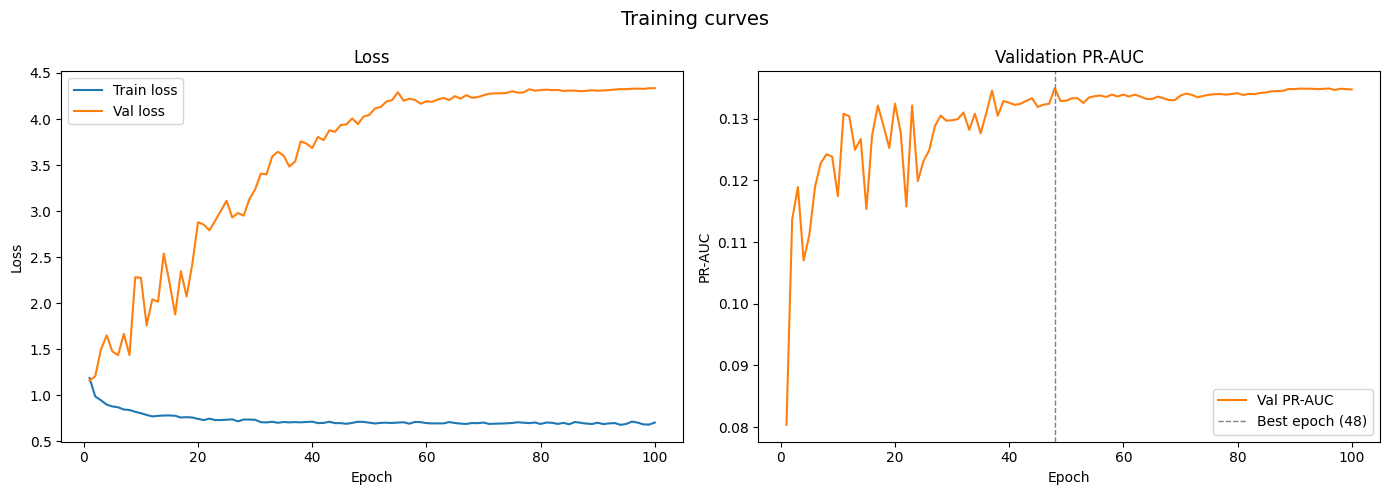

In [34]:
# --- Plot ---
epochs = range(1, N_EPOCHS + 1)
best_epoch = int(np.argmax(history["val_prauc"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training curves", fontsize=14)

# Loss
axes[0].plot(epochs, history["train_loss"], label="Train loss")
axes[0].plot(epochs, history["val_loss"], label="Val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# PR-AUC
axes[1].plot(epochs, history["val_prauc"], color="tab:orange", label="Val PR-AUC")
axes[1].axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"Best epoch ({best_epoch})")
axes[1].set_title("Validation PR-AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("PR-AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

## Create submission CSV

In [35]:
from torch.utils.data import DataLoader

test_loader = DataLoader(test_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False)

best_model.eval()
test_probs = []

with torch.no_grad():
    for X_cat_batch, X_num_batch in test_loader:
        X_cat_batch = X_cat_batch.to(device)
        X_num_batch = X_num_batch.to(device)

        probs = torch.sigmoid(best_model(X_cat_batch, X_num_batch))
        test_probs.extend(probs.cpu().numpy().flatten())

submission = pd.DataFrame({
    "index": range(len(test_x_df)),
    "ID": test_x_df["ID"],
    "fraud_flag": test_probs
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print(f"\nsubmission.csv saved! ({len(submission)} rows)")

   index     ID    fraud_flag
0      0  64707  2.897697e-28
1      1  63919  1.081126e-23
2      2  15664  1.390069e-01
3      3   6626  5.648755e-01
4      4  26766  7.329038e-06

submission.csv saved! (23198 rows)
